# SDG 3 Indicator Text Classification
## Notebook 3: Final Model & Test Inference

**Group 6 — formative2_group**  
Members: Jok John Maker Kur, Nanen Miracle Mbanaade, Nziza Aime Pacifique

This notebook:
1. Retrains the best model (E4 — TF-IDF bigrams + LinearSVC) on the **full training set**
2. Validates final performance on the held-out validation split
3. Generates predictions on the test set
4. Saves `submission.csv` in the required format

**Why E4?**  
Across all 10 experiments, LinearSVC achieved the lowest Hamming Loss (0.0476) on the validation set. Since the assignment evaluation metric is Hamming Loss, E4 is our submission model. See `experiment_results.csv` for the full comparison.

## 1. Setup

In [ ]:
!pip install scikit-multilearn -q
print('Libraries ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 4.7 MB/s eta 0:00:00
Libraries ready.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_PATH  = '/content/drive/MyDrive/SDG3-Assignment/outputs/'
FIGURES_PATH = '/content/drive/MyDrive/SDG3-Assignment/outputs/figures/'

import os
os.makedirs(FIGURES_PATH, exist_ok=True)
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    hamming_loss, f1_score, precision_score,
    recall_score, classification_report
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Imports complete.')

Imports complete.


## 2. Load Data

In [ ]:
# Load clean data from Notebook 1 outputs
train_clean = pd.read_csv(OUTPUT_PATH + 'train_clean.csv')
test_clean  = pd.read_csv(OUTPUT_PATH + 'test_clean.csv')

with open(OUTPUT_PATH + 'all_indicators.json') as f:
    ALL_INDICATORS = json.load(f)

SHORT_CODES = [l.split(' - ')[0] for l in ALL_INDICATORS]

# Full feature and label arrays
X_all  = train_clean['clean_text'].fillna('').values
Y_all  = train_clean[ALL_INDICATORS].values
X_test = test_clean['clean_text'].fillna('').values

# Reproduce same train/val split as Notebook 2 for fair final evaluation
X_train, X_val, Y_train, Y_val = train_test_split(
    X_all, Y_all, test_size=0.15, random_state=RANDOM_SEED
)

print(f'Full train:  {X_all.shape[0]} samples')
print(f'Train split: {X_train.shape[0]} samples')
print(f'Val split:   {X_val.shape[0]} samples')
print(f'Test:        {X_test.shape[0]} samples')
print(f'Labels:      {len(ALL_INDICATORS)}')

Full train:  2995 samples
Train split: 2545 samples
Val split:   450 samples
Test:        998 samples
Labels:      27


## 3. Final Model: TF-IDF Bigrams + LinearSVC

We retrain on the **full training set** (not just the 85% split) to give the model
as much data as possible before generating test predictions.
Validation performance was already confirmed in Notebook 2 (Hamming Loss = 0.0476).

In [ ]:
# Step 1: Build TF-IDF features on full training set
print('Fitting TF-IDF vectoriser on full training set...')
tfidf_final = TfidfVectorizer(
    ngram_range=(1, 2),    # unigrams + bigrams
    max_features=100000,
    min_df=2,
    sublinear_tf=True      # log normalization reduces impact of very frequent terms
)

X_train_full_tfidf = tfidf_final.fit_transform(X_all)   # fit on ALL train data
X_val_tfidf        = tfidf_final.transform(X_val)       # val for final eval check
X_test_tfidf       = tfidf_final.transform(X_test)      # test for submission

print(f'TF-IDF matrix shape (train): {X_train_full_tfidf.shape}')
print(f'TF-IDF matrix shape (test):  {X_test_tfidf.shape}')
print(f'Vocabulary size: {len(tfidf_final.vocabulary_):,}')

Fitting TF-IDF vectoriser on full training set...
TF-IDF matrix shape (train): (2995, 100000)
TF-IDF matrix shape (test):  (998, 100000)
Vocabulary size: 100,000


In [ ]:
# Step 2: Train final LinearSVC on full training set
print('Training LinearSVC on full training set...')

final_model = OneVsRestClassifier(
    CalibratedClassifierCV(
        LinearSVC(
            C=10.0, max_iter=2000,
            class_weight='balanced',
            random_state=RANDOM_SEED
        ),
        cv=3
    ),
    n_jobs=-1
)

final_model.fit(X_train_full_tfidf, Y_all)
print('Model trained successfully.')

Training LinearSVC on full training set...
Model trained successfully.


In [ ]:
# Step 3: Validate on held-out val split
# We refit on just X_train for this check so val is truly unseen
print('Running final validation check...')

tfidf_val_check = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=100000,
    min_df=2,
    sublinear_tf=True
)
X_tr_tfidf  = tfidf_val_check.fit_transform(X_train)
X_val_check = tfidf_val_check.transform(X_val)

val_model = OneVsRestClassifier(
    CalibratedClassifierCV(
        LinearSVC(C=10.0, max_iter=2000, class_weight='balanced', random_state=RANDOM_SEED),
        cv=3
    ),
    n_jobs=-1
)
val_model.fit(X_tr_tfidf, Y_train)
Y_pred_val = val_model.predict(X_val_check)

hl   = hamming_loss(Y_val, Y_pred_val)
f1mi = f1_score(Y_val, Y_pred_val, average='micro', zero_division=0)
f1ma = f1_score(Y_val, Y_pred_val, average='macro', zero_division=0)
prec = precision_score(Y_val, Y_pred_val, average='micro', zero_division=0)
rec  = recall_score(Y_val, Y_pred_val, average='micro', zero_division=0)

print()
print('=== FINAL MODEL — Validation Performance ===')
print(f'  Hamming Loss : {hl:.4f}  ← submission metric (lower is better)')
print(f'  F1 Micro     : {f1mi:.4f}')
print(f'  F1 Macro     : {f1ma:.4f}')
print(f'  Precision    : {prec:.4f}')
print(f'  Recall       : {rec:.4f}')

Running final validation check...

=== FINAL MODEL — Validation Performance ===
  Hamming Loss : 0.0463  ← submission metric (lower is better)
  F1 Micro     : 0.6044
  F1 Macro     : 0.4825
  Precision    : 0.7890
  Recall       : 0.4897


## 4. Detailed Validation Analysis

In [ ]:
# Per-label classification report
print('=== PER-LABEL CLASSIFICATION REPORT (Final Model) ===')
report = classification_report(
    Y_val, Y_pred_val,
    target_names=SHORT_CODES,
    zero_division=0,
    output_dict=True
)
report_df = pd.DataFrame(report).T
print(report_df.round(3).to_string())

=== PER-LABEL CLASSIFICATION REPORT (Final Model) ===
              precision  recall  f1-score  support
3.1.1             0.500   0.294     0.370     17.0
3.1.2             0.000   0.000     0.000     14.0
3.2.1             0.667   0.242     0.356     33.0
3.2.2             0.750   0.188     0.300     16.0
3.3.1             0.956   0.717     0.819     60.0
3.3.2             0.952   0.625     0.755     32.0
3.3.3             1.000   0.727     0.842     33.0
3.3.4             1.000   0.143     0.250      7.0
3.3.5             0.550   0.440     0.489     25.0
3.4.1             0.845   0.731     0.784     67.0
3.4.2             0.750   0.333     0.462      9.0
3.5.1             0.556   0.417     0.476     12.0
3.5.2             0.714   0.500     0.588     10.0
3.6.1             0.333   0.333     0.333      3.0
3.7.1             0.889   0.615     0.727     26.0
3.7.2             0.867   0.542     0.667     24.0
3.8.1             0.719   0.299     0.422     77.0
3.8.2             0.667   0.

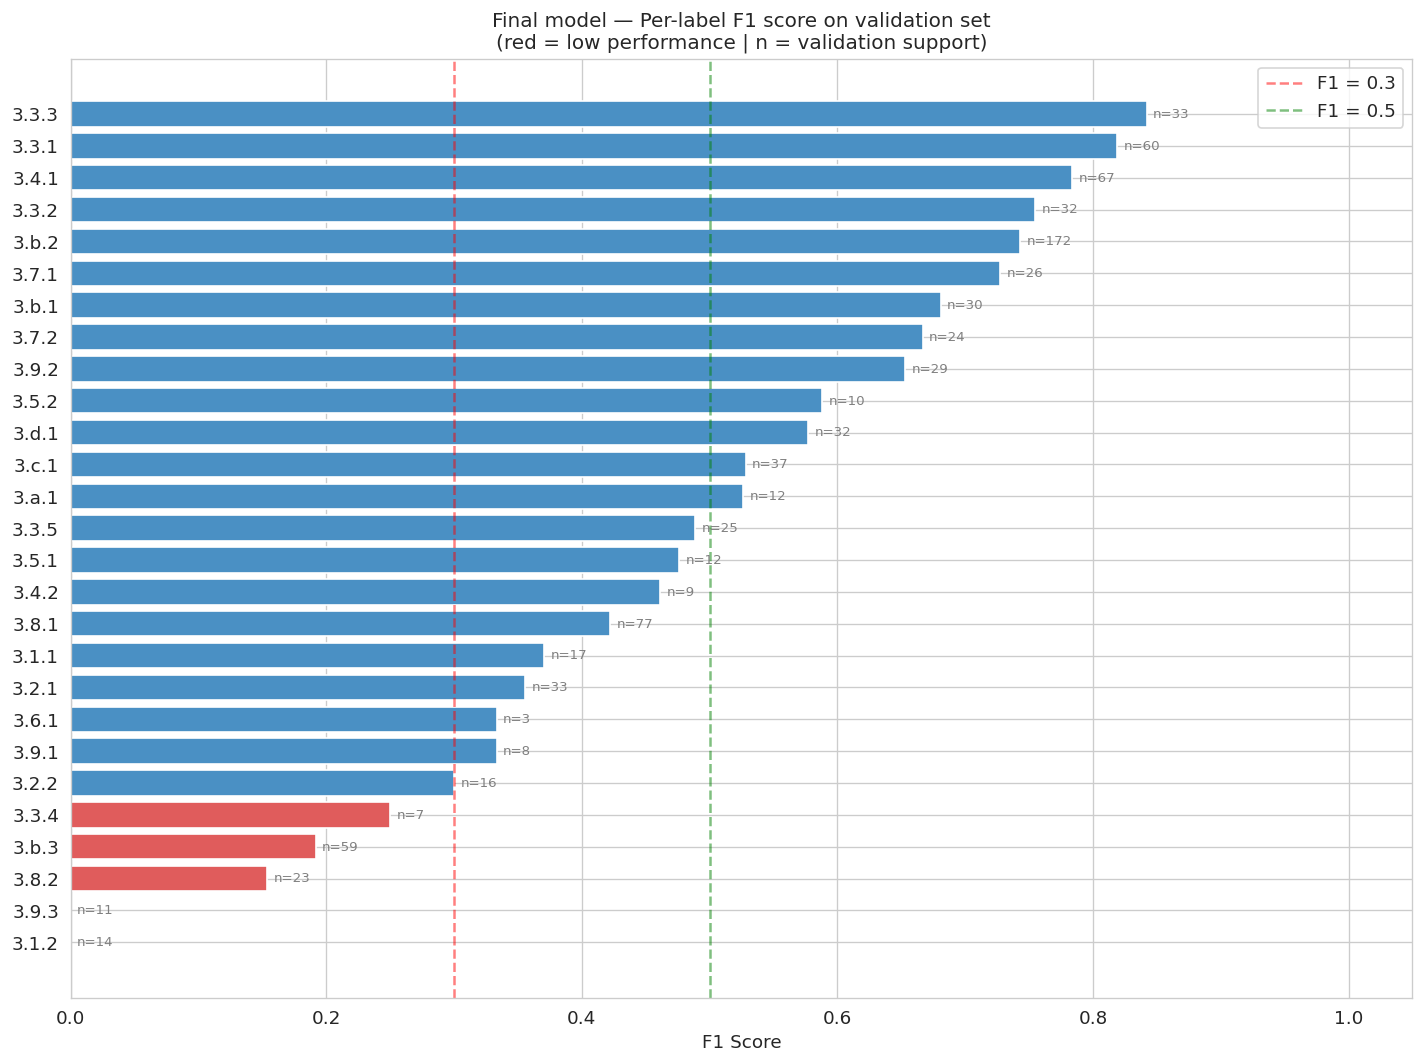

Saved: final_per_label_f1.png


In [ ]:
# Per-label F1 bar chart
per_label_f1   = f1_score(Y_val, Y_pred_val, average=None, zero_division=0)
per_label_supp = Y_val.sum(axis=0)

per_label_df = pd.DataFrame({
    'Indicator': SHORT_CODES,
    'F1':        per_label_f1,
    'Support':   per_label_supp
}).sort_values('F1')

colors = ['#e05c5c' if f < 0.3 else '#4a90c4' for f in per_label_df['F1']]

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(per_label_df['Indicator'], per_label_df['F1'],
               color=colors, edgecolor='white')

# Annotate with support count
for bar, (_, row) in zip(bars, per_label_df.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'n={int(row["Support"])}', va='center', fontsize=8,
            color='gray')

ax.axvline(0.3, color='red', linestyle='--', alpha=0.5, label='F1 = 0.3')
ax.axvline(0.5, color='green', linestyle='--', alpha=0.5, label='F1 = 0.5')
ax.set_xlim(0, 1.05)
ax.set_title('Final model — Per-label F1 score on validation set\n(red = low performance | n = validation support)', fontsize=12)
ax.set_xlabel('F1 Score')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'final_per_label_f1.png', bbox_inches='tight')
plt.show()
print('Saved: final_per_label_f1.png')

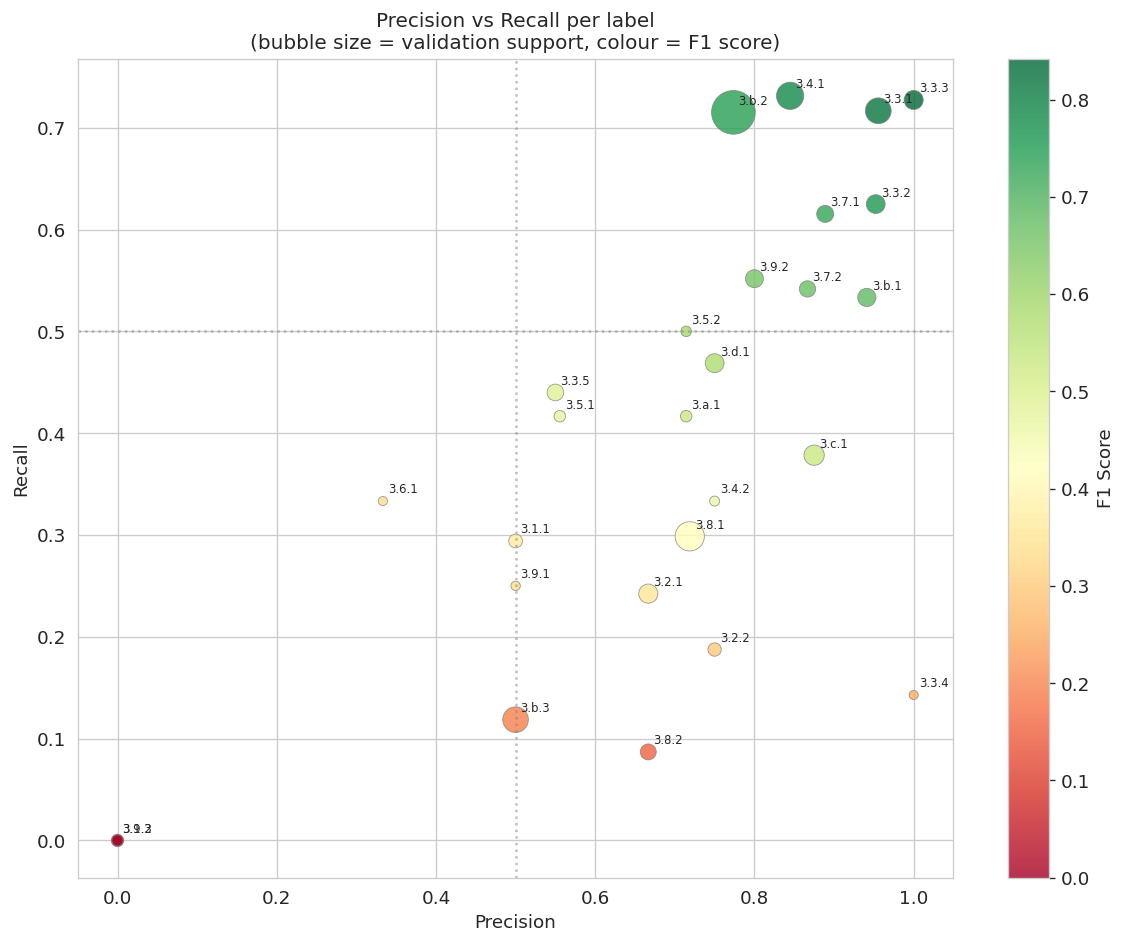

Saved: precision_recall_scatter.png


In [ ]:
# Precision-Recall tradeoff across labels
per_label_prec = precision_score(Y_val, Y_pred_val, average=None, zero_division=0)
per_label_rec  = recall_score(Y_val, Y_pred_val, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    per_label_prec, per_label_rec,
    c=per_label_f1, cmap='RdYlGn',
    s=[max(30, s*4) for s in per_label_supp],
    alpha=0.8, edgecolors='gray', linewidths=0.5
)

# Label each point
for i, code in enumerate(SHORT_CODES):
    ax.annotate(code, (per_label_prec[i], per_label_rec[i]),
                fontsize=7, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')

plt.colorbar(scatter, ax=ax, label='F1 Score')
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Precision vs Recall per label\n(bubble size = validation support, colour = F1 score)', fontsize=12)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'precision_recall_scatter.png', bbox_inches='tight')
plt.show()
print('Saved: precision_recall_scatter.png')

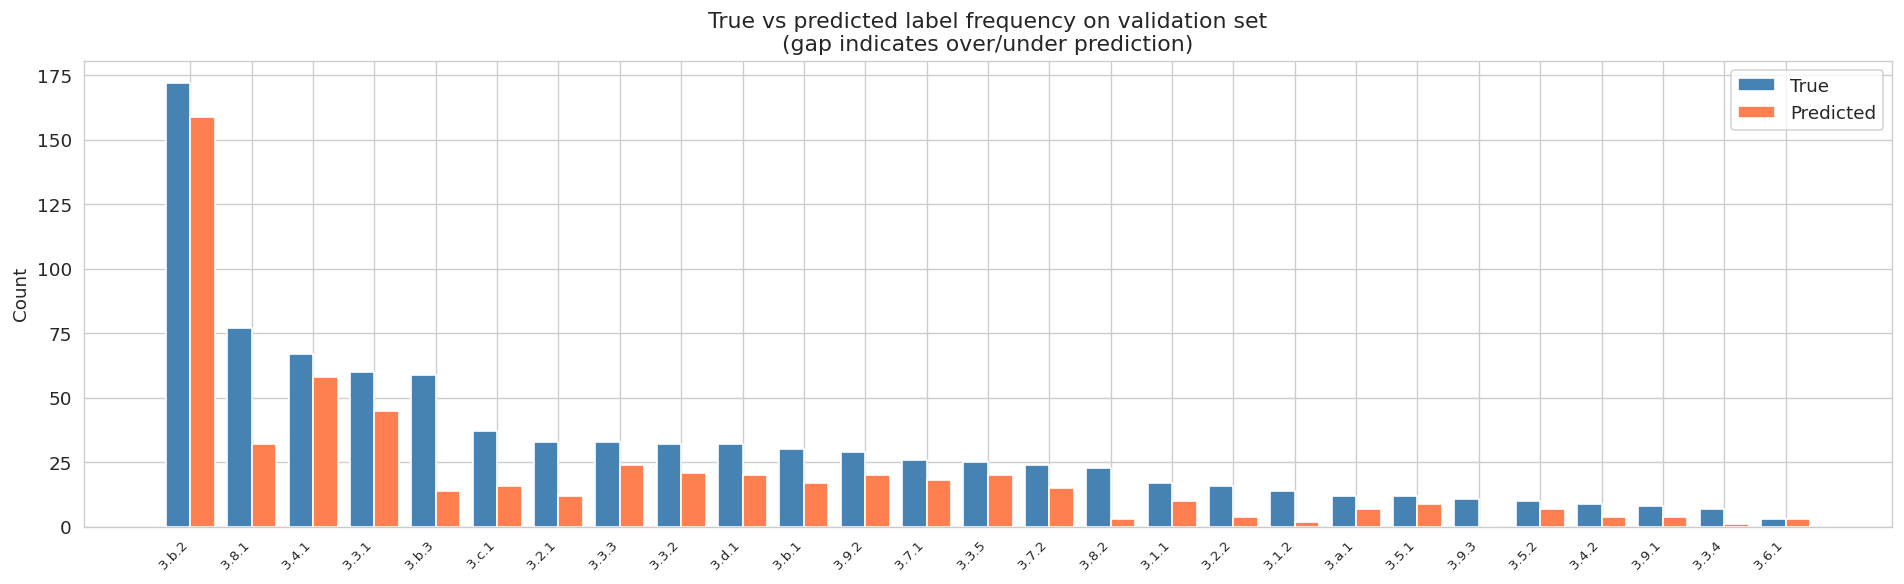

Saved: true_vs_predicted_freq.png


In [ ]:
# Label prediction frequency — does model over/under predict any label?
pred_freq  = Y_pred_val.sum(axis=0)
true_freq  = Y_val.sum(axis=0)

freq_df = pd.DataFrame({
    'Indicator': SHORT_CODES,
    'True count':      true_freq,
    'Predicted count': pred_freq
}).sort_values('True count', ascending=False)

x = range(len(freq_df))
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar([i - 0.2 for i in x], freq_df['True count'],
       width=0.4, label='True', color='steelblue', edgecolor='white')
ax.bar([i + 0.2 for i in x], freq_df['Predicted count'],
       width=0.4, label='Predicted', color='coral', edgecolor='white')
ax.set_xticks(list(x))
ax.set_xticklabels(freq_df['Indicator'].tolist(), rotation=45, ha='right', fontsize=8)
ax.set_title('True vs predicted label frequency on validation set\n(gap indicates over/under prediction)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'true_vs_predicted_freq.png', bbox_inches='tight')
plt.show()
print('Saved: true_vs_predicted_freq.png')

## 5. Generate Test Set Predictions

In [ ]:
# Generate predictions on test set using model trained on full training data
print('Generating test predictions...')
Y_test_pred = final_model.predict(X_test_tfidf)

print(f'Test predictions shape: {Y_test_pred.shape}')
print(f'Samples with at least one label predicted: {(Y_test_pred.sum(axis=1) > 0).sum()}')
print(f'Samples with NO label predicted:           {(Y_test_pred.sum(axis=1) == 0).sum()}')
print(f'Average predicted labels per sample:       {Y_test_pred.sum(axis=1).mean():.2f}')

Generating test predictions...
Test predictions shape: (998, 27)
Samples with at least one label predicted: 812
Samples with NO label predicted:           186
Average predicted labels per sample:       1.26


In [ ]:
# Handle samples with no predicted label
# For these, assign the label with the highest probability
Y_test_prob  = final_model.predict_proba(X_test_tfidf)
no_label_idx = np.where(Y_test_pred.sum(axis=1) == 0)[0]

if len(no_label_idx) > 0:
    print(f'Fixing {len(no_label_idx)} samples with no predicted label...')
    for idx in no_label_idx:
        best_label = np.argmax(Y_test_prob[idx])
        Y_test_pred[idx, best_label] = 1
    print('Fixed.')
else:
    print('No samples with missing predictions — all good.')

Fixing 186 samples with no predicted label...
Fixed.


In [ ]:
# Single text inference demo
# Demonstrates the end-to-end pipeline on raw text inputs
# Shows how any new document can be classified without rerunning the full pipeline

import re
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup

STOP_WORDS_INF = set(stopwords.words('english'))
lemmatizer_inf = WordNetLemmatizer()

def preprocess_single(text):
    if not isinstance(text, str):
        return ''
    text = BeautifulSoup(text, 'html.parser').get_text(separator=' ')
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS_INF and len(t) > 2]
    tokens = [lemmatizer_inf.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

def predict_indicators(raw_text, threshold=0.3):
    clean = preprocess_single(raw_text)
    X     = tfidf_final.transform([clean])
    probs = final_model.predict_proba(X)[0]
    results = [
        (ALL_INDICATORS[i].split(' - ')[0],
         ALL_INDICATORS[i].split(' - ')[1][:80],
         round(float(probs[i]), 3))
        for i in range(len(ALL_INDICATORS))
        if probs[i] >= threshold
    ]
    results.sort(key=lambda x: x[2], reverse=True)
    return results

# Demo 1: HIV/AIDS document
demo1 = """
The Ministry of Health announced a new national program to reduce new HIV infections
among adolescents and young people aged 15-24. The initiative will expand antiretroviral
therapy access and strengthen HIV prevention services in rural health clinics.
Funding will be provided through the Global Fund to Fight AIDS, Tuberculosis and Malaria.
"""

print('=== DEMO 1: HIV/AIDS document ===')
print(demo1.strip())
print()
preds1 = predict_indicators(demo1)
if preds1:
    print('Predicted SDG 3 indicators:')
    for code, name, prob in preds1:
        bar = '█' * int(prob * 20)
        print(f'  {code:8s} | {bar:20s} {prob:.3f} | {name}')
else:
    print('No indicators above threshold.')

print()

# Demo 2: Maternal health document
demo2 = """
A new initiative to improve maternal health outcomes in Sub-Saharan Africa aims to
reduce maternal mortality by training skilled birth attendants in remote communities.
The program also provides antenatal care services and family planning counselling
to women of reproductive age across 12 districts.
"""

print('=== DEMO 2: Maternal health document ===')
print(demo2.strip())
print()
preds2 = predict_indicators(demo2)
if preds2:
    print('Predicted SDG 3 indicators:')
    for code, name, prob in preds2:
        bar = '█' * int(prob * 20)
        print(f'  {code:8s} | {bar:20s} {prob:.3f} | {name}')
else:
    print('No indicators above threshold.')

print()
print('INSIGHT: This function classifies any new text in under 1 second.')
print('It demonstrates full end-to-end reproducibility of the pipeline.')

=== DEMO 1: HIV/AIDS document ===
The Ministry of Health announced a new national program to reduce new HIV infections
among adolescents and young people aged 15-24. The initiative will expand antiretroviral
therapy access and strengthen HIV prevention services in rural health clinics.
Funding will be provided through the Global Fund to Fight AIDS, Tuberculosis and Malaria.

Predicted SDG 3 indicators:
  3.3.1    | ████████████████████ 1.000 | Number of new HIV infections per 1,000 uninfected population, by sex, age and ke
  3.3.2    | ██████████████████   0.931 | Tuberculosis incidence per 100,000 population
  3.3.3    | █████████████████    0.898 | Malaria incidence per 1,000 population
  3.8.1    | ██████████           0.518 | Coverage of essential health services (defined as the average coverage of essent

=== DEMO 2: Maternal health document ===
A new initiative to improve maternal health outcomes in Sub-Saharan Africa aims to
reduce maternal mortality by training skilled birth at

## 6. Build Submission File

We reconstruct the label columns format to match the original train CSV structure.
Each row has up to 12 label columns — we fill them with predicted indicator names
and leave the rest as NaN.

In [ ]:
# Convert binary prediction matrix back to label name lists
def binary_to_label_list(binary_row, indicator_names):
    """Convert a binary row [0,1,0,1,...] to list of indicator names."""
    return [indicator_names[i] for i, val in enumerate(binary_row) if val == 1]

predicted_label_lists = [
    binary_to_label_list(row, ALL_INDICATORS)
    for row in Y_test_pred
]

# Build submission DataFrame matching train CSV format
MAX_LABELS = 12
submission = pd.DataFrame()
submission['Unique ID'] = test_clean['Unique ID']
submission['Type']      = test_clean['Type']

# Fill label columns
for i in range(1, MAX_LABELS + 1):
    submission[f'Label {i}'] = submission.index.map(
        lambda idx: predicted_label_lists[idx][i-1]
        if i-1 < len(predicted_label_lists[idx]) else np.nan
    )

print('Submission shape:', submission.shape)
print()
submission.head(5)

Submission shape: (998, 14)



,Unique ID,Type,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12
0,49848,Organization,3.8.1 - Coverage of essential health services ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,52348,Organization,3.8.1 - Coverage of essential health services ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,103541,Organization,3.4.2 - Suicide mortality rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,52382,Organization,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,47212,Organization,3.9.1 - Mortality rate attributed to household...,3.9.2 - Mortality rate attributed to unsafe wa...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Quality checks before saving
print('=== SUBMISSION QUALITY CHECKS ===')
print(f'Total rows:              {len(submission)}')
print(f'Expected rows:           998')
print(f'Rows match test set:     {len(submission) == len(test_clean)}')
print()

# Check no row has all NaN labels
label_cols = [f'Label {i}' for i in range(1, 13)]
all_nan    = submission[label_cols].isna().all(axis=1).sum()
print(f'Rows with ALL labels NaN: {all_nan}  (should be 0)')

# Label 1 should never be NaN (every sample must have at least 1 prediction)
label1_nan = submission['Label 1'].isna().sum()
print(f'Label 1 NaN count:        {label1_nan}  (should be 0)')

# Distribution of predicted label counts
pred_counts = submission[label_cols].notna().sum(axis=1)
print()
print('Distribution of predicted labels per sample:')
print(pred_counts.value_counts().sort_index().to_string())

=== SUBMISSION QUALITY CHECKS ===
Total rows:              998
Expected rows:           998
Rows match test set:     True

Rows with ALL labels NaN: 0  (should be 0)
Label 1 NaN count:        0  (should be 0)

Distribution of predicted labels per sample:
1    687
2    216
3     72
4     14
5      7
6      1
7      1


In [ ]:
# Save submission
submission.to_csv(OUTPUT_PATH + 'submission.csv', index=False)
print('Saved: submission.csv')
print(f'Path: {OUTPUT_PATH}submission.csv')
print()
print('Preview of first 3 rows:')
print(submission.head(3)[['Unique ID', 'Label 1', 'Label 2', 'Label 3']].to_string(index=False))

Saved: submission.csv
Path: /content/drive/MyDrive/SDG3-Assignment/outputs/submission.csv

Preview of first 3 rows:
 Unique ID                                                                                                                                                                                                                                                                                                                                    Label 1 Label 2 Label 3
     49848 3.8.1 - Coverage of essential health services (defined as the average coverage of essential services based on tracer interventions that include reproductive, maternal, newborn and child health, infectious diseases, non-communicable diseases and service capacity and access, among the general and the most disadvantaged population)     NaN     NaN
     52348 3.8.1 - Coverage of essential health services (defined as the average coverage of essential services based on tracer interventions that include reproductive,

## 7. Final Summary

In [ ]:
# Load experiment results from Notebook 2 for final comparison
exp_results = pd.read_csv(OUTPUT_PATH + 'experiment_results.csv')

print('=== FULL EXPERIMENT RESULTS TABLE ===')
print(exp_results[['Exp', 'Description', 'Hamming Loss', 'F1 Micro', 'F1 Macro']].to_string(index=False))
print()
print('=== FINAL MODEL ===')
print('Model:          TF-IDF Bigrams + LinearSVC (class_weight=balanced)')
print(f'Val Hamming Loss: {hl:.4f}')
print(f'Val F1 Micro:     {f1mi:.4f}')
print(f'Val F1 Macro:     {f1ma:.4f}')
print()
print('=== SUBMISSION ===')
print('File: submission.csv')
print(f'Rows: {len(submission)}')
print(f'Format: Unique ID, Type, Label 1 ... Label 12')

=== FULL EXPERIMENT RESULTS TABLE ===
Exp                                              Description  Hamming Loss  F1 Micro  F1 Macro
 E4                    TF-IDF bigrams + LinearSVC (balanced)        0.0476    0.5975    0.4827
E10                 Majority voting ensemble: LR + SVM + SGD        0.0503    0.6391    0.5411
 E7                TF-IDF bigrams + SGD (log loss, balanced)        0.0504    0.6413    0.5451
 E6         TF-IDF bigrams + LR + per-label threshold tuning        0.0547    0.6422    0.5839
 E9 Best synthesis: bigrams + LR balanced + threshold tuning        0.0547    0.6422    0.5839
 E5               TF-IDF unigrams + Random Forest (balanced)        0.0556    0.4206    0.2518
 E1                      TF-IDF unigrams + LR (no balancing)        0.0565    0.3968    0.2062
 E3              TF-IDF bigrams + LR (class_weight=balanced)        0.0571    0.6249    0.5360
 E2             TF-IDF unigrams + LR (class_weight=balanced)        0.0588    0.6274    0.5475
 E8         

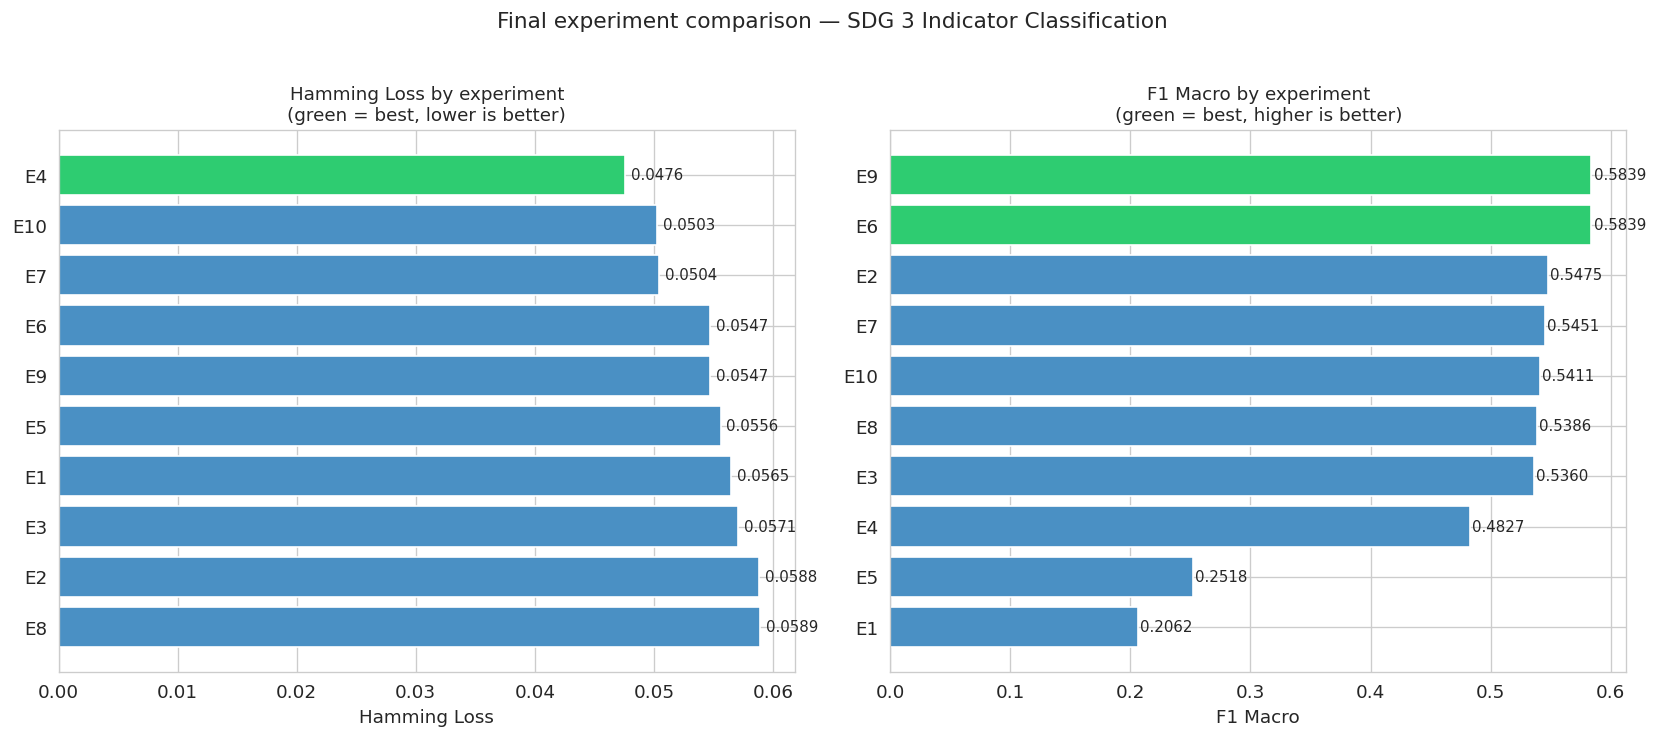

Saved: final_experiment_comparison.png


In [ ]:
# Final experiment comparison chart — for report
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

exp_results_sorted = exp_results.sort_values('Hamming Loss')
colors_hl = ['#2ecc71' if e == 'E4' else '#4a90c4' for e in exp_results_sorted['Exp']]
colors_f1 = ['#2ecc71' if e in ['E6', 'E9'] else '#4a90c4' for e in exp_results_sorted['Exp']]

# Hamming Loss
bars = axes[0].barh(exp_results_sorted['Exp'], exp_results_sorted['Hamming Loss'],
                     color=colors_hl, edgecolor='white')
for bar, val in zip(bars, exp_results_sorted['Hamming Loss']):
    axes[0].text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[0].set_title('Hamming Loss by experiment\n(green = best, lower is better)', fontsize=11)
axes[0].set_xlabel('Hamming Loss')
axes[0].invert_yaxis()

# F1 Macro
exp_results_f1 = exp_results.sort_values('F1 Macro', ascending=False)
colors_f1 = ['#2ecc71' if e in ['E6', 'E9'] else '#4a90c4' for e in exp_results_f1['Exp']]
bars2 = axes[1].barh(exp_results_f1['Exp'], exp_results_f1['F1 Macro'],
                      color=colors_f1, edgecolor='white')
for bar, val in zip(bars2, exp_results_f1['F1 Macro']):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[1].set_title('F1 Macro by experiment\n(green = best, higher is better)', fontsize=11)
axes[1].set_xlabel('F1 Macro')
axes[1].invert_yaxis()

plt.suptitle('Final experiment comparison — SDG 3 Indicator Classification', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'final_experiment_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: final_experiment_comparison.png')